# 🚀 Data Cleaning and Preprocessing Fundamentals

## 🎯 Objectives

This project focuses on understanding and implementing core data preprocessing techniques including:

- Handling missing values
- Identifying and removing duplicate records
- Detecting and treating outliers
- Standardizing column formats
- Improving overall data quality


In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
plt.style.use("ggplot")

In [61]:
df=pd.read_excel("netflix1.xlsx")

## 📊 Initial Data Exploration

In this section, the dataset is explored to understand its structure, data types, and overall composition before applying any cleaning techniques.

In [62]:
df.head()

,User ID,Subscription Type,Monthly Revenue,Join Date,Last Payment Date,Country,Age,Gender,Device,Plan Duration,Payment_Method
0,1.0,Basic,10.0,NaT,2023-06-10,United States,28.0,Male,NaN,1 Month,Credit Card
1,2.0,Premium,15.0,2021-09-05,NaT,Canada,35.0,Female,Tablet,1 Month,Net Banking
2,3.0,Standard,12.0,2023-02-28,2023-06-27,NaN,42.0,Male,Smart TV,1 Month,Net Banking
3,4.0,Standard,12.0,2022-07-10,2023-06-26,Australia,51.0,Female,Laptop,1 Month,UPI
4,5.0,Basic,10.0,2023-05-01,2023-06-28,NaN,33.0,Male,NaN,1 Month,UPI


In [63]:
df.shape

(2502, 11)

In [64]:
df.columns

Index(['User ID', 'Subscription Type', 'Monthly Revenue', 'Join Date',
       'Last Payment Date', 'Country', 'Age', 'Gender', 'Device',
       'Plan Duration', 'Payment_Method'],
      dtype='object')

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2502 entries, 0 to 2501
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   User ID            2053 non-null   float64       
 1   Subscription Type  1806 non-null   object        
 2   Monthly Revenue    2025 non-null   float64       
 3   Join Date          1799 non-null   datetime64[ns]
 4   Last Payment Date  1786 non-null   datetime64[ns]
 5   Country            1755 non-null   object        
 6   Age                1856 non-null   float64       
 7   Gender             1816 non-null   object        
 8   Device             1836 non-null   object        
 9   Plan Duration      1786 non-null   object        
 10  Payment_Method     2048 non-null   object        
dtypes: datetime64[ns](2), float64(3), object(6)
memory usage: 215.1+ KB


In [66]:
df.describe()

,User ID,Monthly Revenue,Join Date,Last Payment Date,Age
count,2053.000000,2025.000000,1799,1786,1856.000000
mean,1251.482708,12.779259,2022-08-28 19:16:38.554752768,2023-07-03 12:27:24.792833280,38.818966
min,1.000000,10.000000,2021-09-05 00:00:00,2023-06-10 00:00:00,26.000000
25%,615.000000,11.000000,2022-07-15 00:00:00,2023-06-29 00:00:00,32.000000
50%,1256.000000,12.000000,2022-08-31 00:00:00,2023-07-04 00:00:00,39.000000
75%,1877.000000,14.000000,2022-10-18 00:00:00,2023-07-08 00:00:00,45.000000
max,2502.000000,400.000000,2023-06-14 00:00:00,2023-07-15 00:00:00,70.000000
std,725.967818,9.291405,NaN,NaN,7.235104


In [67]:
df.dtypes

User ID                     float64
Subscription Type            object
Monthly Revenue             float64
Join Date            datetime64[ns]
Last Payment Date    datetime64[ns]
Country                      object
Age                         float64
Gender                       object
Device                       object
Plan Duration                object
Payment_Method               object
dtype: object

## 🔁 Duplicate Handling

Duplicate records can negatively affect analysis and model performance. This step identifies duplicate rows and removes them to maintain data integrity.

In [68]:
df.duplicated().sum()

np.int64(95)

In [69]:
df.drop_duplicates(inplace=True)

In [70]:
df.shape

(2407, 11)

The dataset originally contained **2502**. 
After removing duplicate records, **2407** remain. 
A total of **95 duplicate rows** were removed to ensure data uniqueness.
Duplicates were identified and removed to ensure each record represents unique information.

## ❓ Missing Value Analysis

Missing values were analyzed at both column and row levels to understand their distribution and impact on the dataset.

In [71]:
df.isnull().sum()

User ID              354
Subscription Type    608
Monthly Revenue      388
Join Date            608
Last Payment Date    622
Country              655
Age                  551
Gender               592
Device               573
Plan Duration        625
Payment_Method       365
dtype: int64

In [72]:
(df.isnull().sum()/df.shape[0])*100

User ID              14.707104
Subscription Type    25.259659
Monthly Revenue      16.119651
Join Date            25.259659
Last Payment Date    25.841296
Country              27.212297
Age                  22.891566
Gender               24.594931
Device               23.805567
Plan Duration        25.965933
Payment_Method       15.164105
dtype: float64

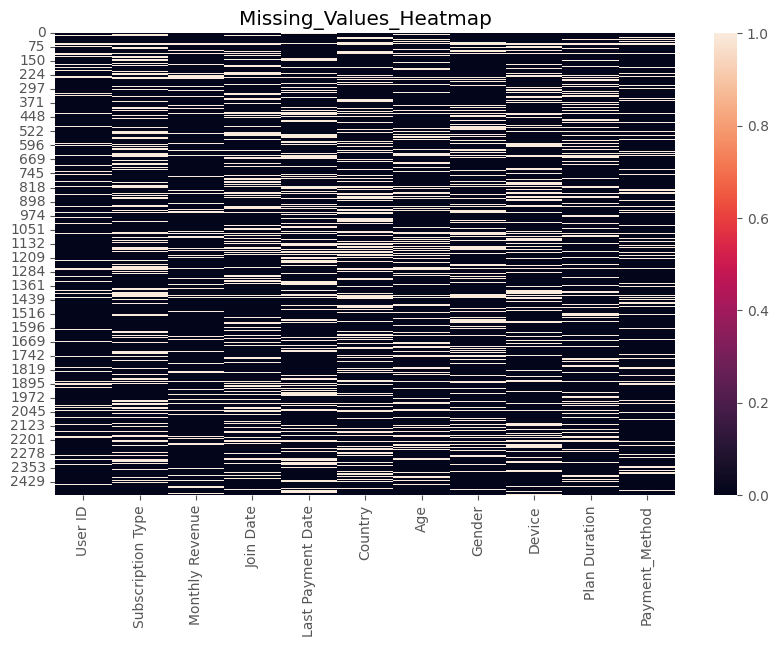

In [73]:

plt.figure(figsize=(10,6))
sns.heatmap(df.isnull())
plt.title("Missing_Values_Heatmap")
plt.savefig("missingvalues_heatmap.png")
plt.show()


In [74]:
df

,User ID,Subscription Type,Monthly Revenue,Join Date,Last Payment Date,Country,Age,Gender,Device,Plan Duration,Payment_Method
0,1.0,Basic,10.0,NaT,2023-06-10,United States,28.0,Male,NaN,1 Month,Credit Card
1,2.0,Premium,15.0,2021-09-05,NaT,Canada,35.0,Female,Tablet,1 Month,Net Banking
2,3.0,Standard,12.0,2023-02-28,2023-06-27,NaN,42.0,Male,Smart TV,1 Month,Net Banking
3,4.0,Standard,12.0,2022-07-10,2023-06-26,Australia,51.0,Female,Laptop,1 Month,UPI
4,5.0,Basic,10.0,2023-05-01,2023-06-28,NaN,33.0,Male,NaN,1 Month,UPI
...,...,...,...,...,...,...,...,...,...,...,...
2497,2498.0,Standard,12.0,2022-08-09,2023-07-15,United States,38.0,Male,NaN,1 Month,PayPal
2498,2499.0,Standard,13.0,NaT,2023-07-12,Canada,48.0,Female,Tablet,1 Month,Credit Card
2499,2500.0,Basic,15.0,2022-08-13,2023-07-12,United States,35.0,Female,Smart TV,NaN,PayPal
2500,2501.0,Standard,150.0,NaT,NaT,Canada,70.0,Male,Tablet,1 Month,Credit Card


In [75]:
df = df.dropna(how='all')

In [76]:
df.shape

(2406, 11)

## Missing Values Visualization (Heatmap)

A heatmap was used to visually identify missing values in the dataset. 
It helped detect patterns of null values across rows and columns, 
making it easier to decide how to handle missing data.

In [77]:
(df.isnull().sum(axis=1) / df.shape[1]) * 100

0       18.181818
1        9.090909
2        9.090909
3        0.000000
4       18.181818
          ...    
2497     9.090909
2498     9.090909
2499     9.090909
2500    18.181818
2501    18.181818
Length: 2406, dtype: float64

In [78]:
df.isnull().all(axis=1).sum()

np.int64(0)

In [79]:
row_missing_percent = (df.isnull().sum(axis=1) / df.shape[1]) * 100

In [80]:
df = df[row_missing_percent <= 70]
df.shape

(2293, 11)

Rows with more than 70% missing values were removed because they lacked sufficient information for meaningful analysis. Retaining such rows could introduce bias and reduce data quality.

#  🗺️ Missing Value Heatmap

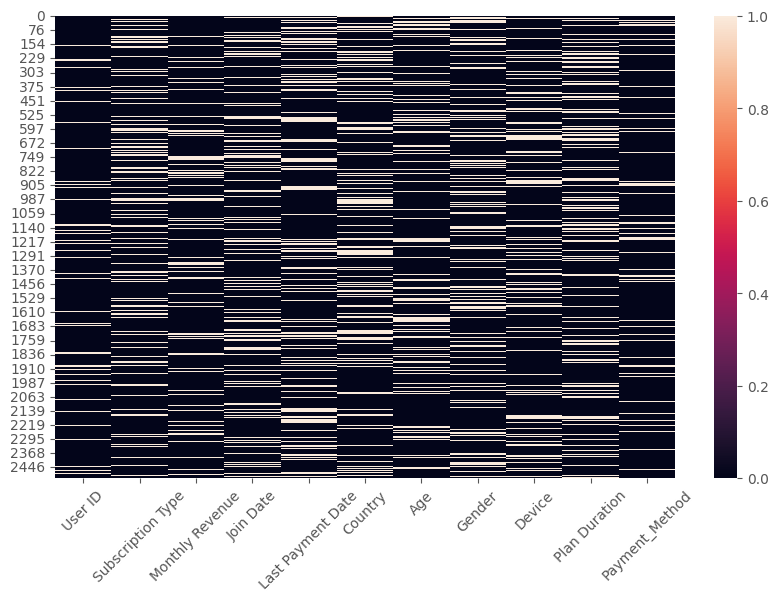

In [81]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(),cbar="verdis")
plt.xticks(rotation=45)
plt.savefig("missingvalues_heatmap.png")
plt.show()

# 🧹 Column Standardization

In [82]:
df.columns = df.columns.str.strip().str.replace(" ", "_", regex=False)

In [83]:
df.columns

Index(['User_ID', 'Subscription_Type', 'Monthly_Revenue', 'Join_Date',
       'Last_Payment_Date', 'Country', 'Age', 'Gender', 'Device',
       'Plan_Duration', 'Payment_Method'],
      dtype='object')

In [84]:
df.drop(columns="Join_Date",inplace=True)

In [85]:
df.drop(columns="Last_Payment_Date",inplace=True)

In [86]:
for i in df.select_dtypes(include="object").columns:
    df[i].fillna(df[i].mode()[0],inplace=True)

C:\Users\arsha\AppData\Local\Temp\ipykernel_17960\3052609891.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[i].fillna(df[i].mode()[0],inplace=True)


In [87]:
df['UserID'] = range(1, len(df) + 1)

In [88]:
df["UserID"].isnull().sum()

np.int64(0)

In [89]:
for i in df.select_dtypes(include="float64").columns:
    df[i].fillna(df[i].median(),inplace=True)

C:\Users\arsha\AppData\Local\Temp\ipykernel_17960\18337418.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[i].fillna(df[i].median(),inplace=True)
C:\Users\arsha\AppData\Local\Temp\ipykernel_17960\18337418.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when 

In [90]:
df.isnull().sum()

User_ID              0
Subscription_Type    0
Monthly_Revenue      0
Country              0
Age                  0
Gender               0
Device               0
Plan_Duration        0
Payment_Method       0
UserID               0
dtype: int64

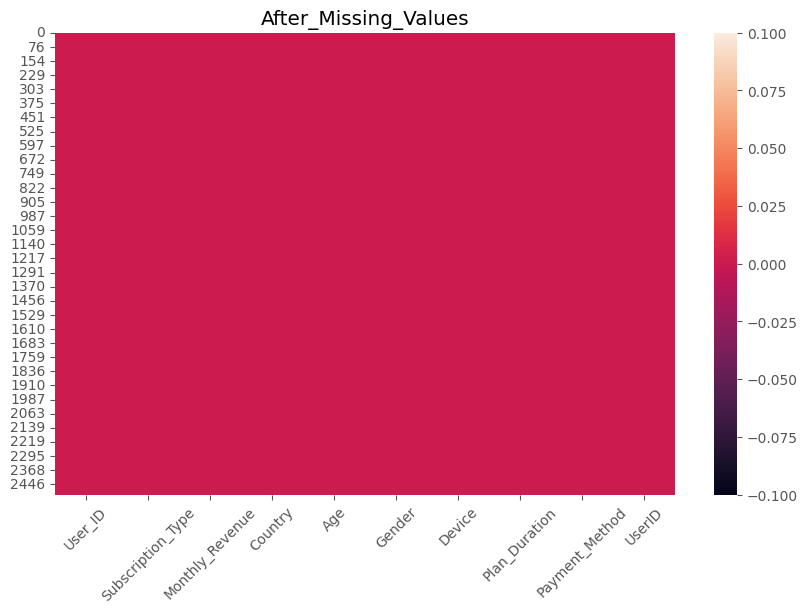

In [91]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(),cbar="verdis")
plt.xticks(rotation=45)
plt.title("After_Missing_Values")
plt.savefig("After_Missing_Values_heatmap.png")
plt.show()



The heatmap was used again to check the dataset after cleaning missing values. 
It shows that most missing data has been handled and the dataset is now more complete and ready for further analysis.

## 🔥 Outlier Detection


In [92]:
df.describe()

,User_ID,Monthly_Revenue,Age,UserID
count,2293.000000,2293.000000,2293.000000,2293.000000
mean,1249.786306,12.682076,38.856520,1147.000000
std,683.811937,8.733729,6.458412,662.076405
min,1.000000,10.000000,26.000000,1.000000
25%,689.000000,11.000000,34.000000,574.000000
50%,1252.000000,12.000000,39.000000,1147.000000
75%,1799.000000,14.000000,43.000000,1720.000000
max,2502.000000,400.000000,70.000000,2293.000000


In [93]:
df.head()

,User_ID,Subscription_Type,Monthly_Revenue,Country,Age,Gender,Device,Plan_Duration,Payment_Method,UserID
0,1.0,Basic,10.0,United States,28.0,Male,Laptop,1 Month,Credit Card,1
1,2.0,Premium,15.0,Canada,35.0,Female,Tablet,1 Month,Net Banking,2
2,3.0,Standard,12.0,Spain,42.0,Male,Smart TV,1 Month,Net Banking,3
3,4.0,Standard,12.0,Australia,51.0,Female,Laptop,1 Month,UPI,4
4,5.0,Basic,10.0,Spain,33.0,Male,Laptop,1 Month,UPI,5


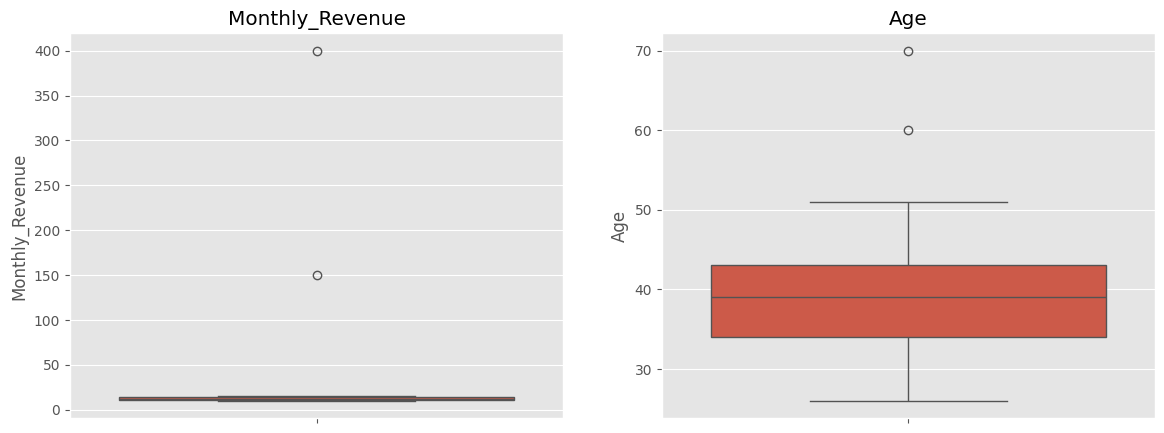

In [94]:
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
sns.boxplot(df["Monthly_Revenue"])
plt.title("Monthly_Revenue")
plt.savefig("Monthly_revenue_outlier.png")
plt.subplot(1,2,2)
sns.boxplot(df["Age"])
plt.title("Age")
plt.savefig("Age.png")


# Removing Outliers

In [98]:
df_iqr=df.copy()

In [99]:
Q1 = df_iqr['Monthly_Revenue'].quantile(0.25)
Q3 = df_iqr['Monthly_Revenue'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df_iqr = df_iqr[(df_iqr['Monthly_Revenue'] <= upper)]
Q1 = df_iqr['Age'].quantile(0.25)
Q3 = df_iqr['Age'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df_iqr = df_iqr[(df_iqr['Age'] <= upper)]

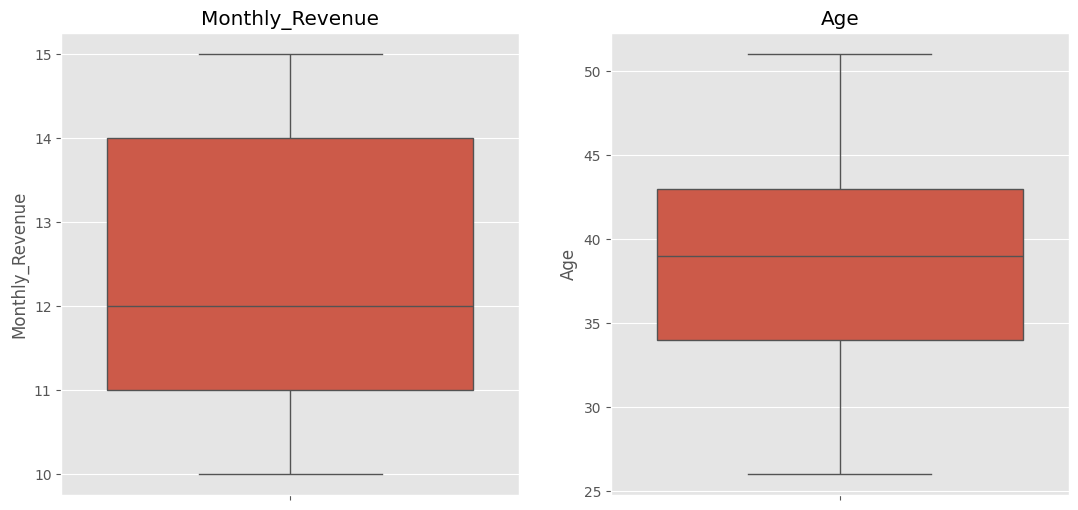

In [100]:
plt.figure(figsize=(13,6))
plt.subplot(1,2,1)
sns.boxplot(df_iqr["Monthly_Revenue"])
plt.title("Monthly_Revenue")
plt.savefig("after_removing_outlier_MonthlyRevenue.png")
plt.subplot(1,2,2)
sns.boxplot(df_iqr["Age"])
plt.title("Age")
plt.savefig("after_removing_outlier_Age.png")

Outliers were handled carefully to maintain realistic data ranges while preserving meaningful variability.

In [101]:
df_iqr.shape

(2291, 10)

The final cleaned dataset contains 2293 rows and 10 columns.

## ✅ Final Dataset Summary

After completing the preprocessing steps:

- Duplicate records were removed
- Missing values were handled appropriately
- Rows with excessive missing data were dropped
- Outliers were analyzed and treated
- Column names were standardized

The dataset is now clean, structured, and ready for advanced preprocessing steps such as encoding, feature scaling, and machine learning modeling in the next project.

In [39]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 2293 entries, 0 to 2501
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   User_ID            2293 non-null   float64
 1   Subscription_Type  2293 non-null   object 
 2   Monthly_Revenue    2293 non-null   float64
 3   Country            2293 non-null   object 
 4   Age                2293 non-null   float64
 5   Gender             2293 non-null   object 
 6   Device             2293 non-null   object 
 7   Plan_Duration      2293 non-null   object 
 8   Payment_Method     2293 non-null   object 
 9   UserID             2293 non-null   int64  
dtypes: float64(3), int64(1), object(6)
memory usage: 197.1+ KB
